<a href="https://colab.research.google.com/github/Rut092/rut-ai-portfolio-PHASE3-Computer-Vision/blob/main/Convolutional_Neural_Network(CIFAR_10).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing the Filters

## Importing the Libraries

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

## Full Convo Model

In [6]:
from torch.nn.modules.dropout import Dropout
class modelCIFAR(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1 -> 3 to 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2 -> 32 to 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2)
        )

        # Block 3 -> 64 to 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size = 3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.MaxPool2d(2)
        )

        # Output Block without flattening it

        self.classifier = nn.Sequential(
            # 128 featurs to exactly 10 classes
            nn.Conv2d(in_channels=128, out_channels=10, kernel_size=1, padding=1),
            # Gap Method to Make Size 1x1
            nn.AdaptiveAvgPool2d(1)

        )

    def forward(self, x, return_maps = False):
        b1 = self.block1(x)
        b2 = self.block2(b1)
        b3 = self.block3(b2)
        out = self.classifier(b3)

        # out batch is 10 x 1 x 1
        # squeezing extra 1 to get [batch,10]
        out = out.view(out.size(0),-1)

        if return_maps == True:
            return b1,b2,b3 # using for visualisation

        return out

## Building the Visualizer

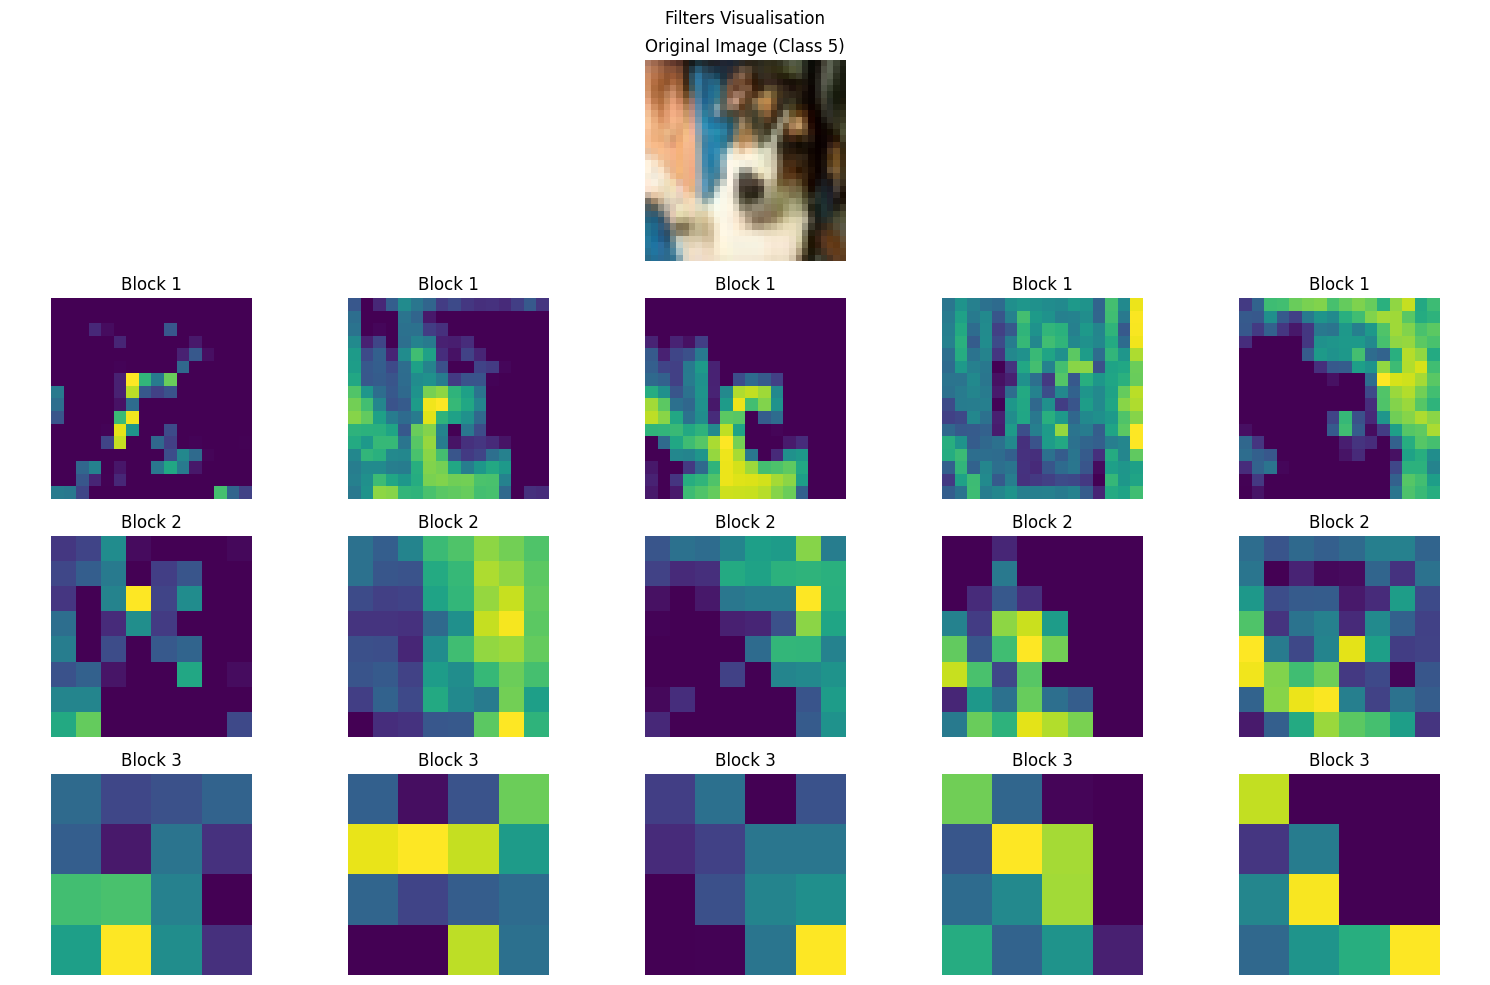

In [9]:
def visualize_filters():

    # loading the tiny data
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)

    loader = torch.utils.data.DataLoader(dataset,batch_size=1,shuffle = True)


    model = modelCIFAR()
    model.eval()

    image,label = next(iter(loader))

    with torch.no_grad():
        map1,map2,map3  = model(image,return_maps=True)

    # Plotting Logic
    fig,axes = plt.subplots(4,5,figsize=(15,10))
    fig.suptitle("Filters Visualisation")

    # Plot the Original Image
    # Convert from [1, C, H, W] to [H, W, C] and unnormalize for display
    img_display = image.squeeze(0).numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    img_display = img_display * std + mean
    img_display = np.clip(img_display, 0, 1) # Ensure values are within [0, 1]

    axes[0,2].imshow(img_display)
    axes[0,2].set_title(f"Original Image (Class {label.item()})")
    axes[0,2].axis('off')

    for ax in axes[0,:]: ax.axis('off') # hide empty slot in top row


    def plot_maps(f_map,row,title):
        # Plotting
        maps = f_map[0].detach().numpy()
        for i in range(5):  # plotting 5 out of 32,64,128
            axes[row,i].imshow(maps[i])
            axes[row,i].set_title(title)
            axes[row,i].axis('off')

    plot_maps(map1,1,"Block 1")
    plot_maps(map2,2,"Block 2")
    plot_maps(map3,3,"Block 3")

    plt.tight_layout()
    plt.show()


visualize_filters()

## Training Dataset

Epoch [1/10], Train Loss: 1.4215, Test Loss: 1.4511, Accuracy: 0.4956
Epoch [2/10], Train Loss: 1.1390, Test Loss: 1.2950, Accuracy: 0.5529
Epoch [3/10], Train Loss: 1.0234, Test Loss: 1.1495, Accuracy: 0.6256
Epoch [4/10], Train Loss: 0.9544, Test Loss: 1.1167, Accuracy: 0.6485
Epoch [5/10], Train Loss: 0.8951, Test Loss: 1.1041, Accuracy: 0.6248
Epoch [6/10], Train Loss: 0.8569, Test Loss: 1.0583, Accuracy: 0.6373
Epoch [7/10], Train Loss: 0.8112, Test Loss: 0.9451, Accuracy: 0.7064
Epoch [8/10], Train Loss: 0.7821, Test Loss: 0.9379, Accuracy: 0.7061
Epoch [9/10], Train Loss: 0.7503, Test Loss: 0.9347, Accuracy: 0.6951
Epoch [10/10], Train Loss: 0.7305, Test Loss: 0.8950, Accuracy: 0.7211


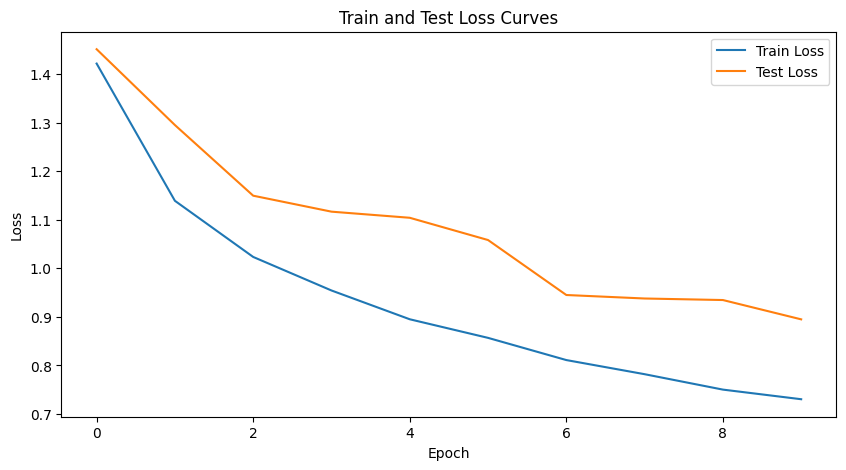

In [12]:
def train_and_evaluate():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(trainset,batch_size=64,shuffle = True)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

    test_loader = torch.utils.data.DataLoader(testset, batch_size=64,
                                            shuffle=False)

    num_epochs = 10
    model = modelCIFAR().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001,weight_decay=1e-4)

    # Tracking Array
    train_loss_arr = []
    test_loss_arr = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        # training

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        train_loss_arr.append(train_loss)

        # validation

        model.eval()
        test_loss = 0.0
        correct = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += torch.sum(preds == labels.data)

            test_loss /= len(test_loader.dataset)
        test_loss_arr.append(test_loss)

        accuracy = correct.double() / len(test_loader.dataset)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.4f}")

    # Plotting the final Curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_arr, label='Train Loss')
    plt.plot(test_loss_arr, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train and Test Loss Curves')
    plt.legend()
    plt.show()

train_and_evaluate()